# Práctica de Autoencoders para auditoría táctica

Este notebook construye mapas de calor de pases por partido, entrena un autoencoder convolucional con temporadas históricamente dominantes del FC Barcelona y evalúa si los partidos de etapas de crisis se alejan de esa identidad táctica aprendida.

El criterio de anomalía será el error de reconstrucción: cuanto mayor sea el MSE, más caótica se considera la estructura espacial de pases.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models


## 1. Carga y separación histórica

No usamos una partición aleatoria. El entrenamiento se construye con temporadas de dominio y estabilidad, mientras que el test se reserva para temporadas de crisis o transición. Así el autoencoder aprende una referencia táctica y después medimos cuánto se desvía cada partido.


In [20]:
# Reproducibilidad y estilo visual.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid", context="talk")

# Ruta local del dataset de la práctica.
CSV_PATH = "dataset_pases_barca_historico_completo.csv"

# Carga del dataset.
df = pd.read_csv(CSV_PATH)

# Validación mínima de columnas críticas para evitar errores silenciosos.
required_columns = {
    "season_id",
    "match_id",
    "minute",
    "player",
    "x_inicio",
    "y_inicio",
    "pass_outcome",
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias en el CSV: {sorted(missing_columns)}")

# División histórica exacta solicitada en la práctica.
season_train_ids = [41, 21, 22, 23, 24, 26, 27, 2, 1, 4]
season_test_ids = [40, 25, 42, 90]

df_train = df[df["season_id"].isin(season_train_ids)].copy()
df_test = df[df["season_id"].isin(season_test_ids)].copy()

if df_train.empty:
    raise ValueError("df_train está vacío. Revisa los valores de season_id de entrenamiento.")
if df_test.empty:
    raise ValueError("df_test está vacío. Revisa los valores de season_id de test.")


def build_heatmaps_from_df(dataframe, bins=64, x_range=(0, 120), y_range=(0, 80)):
    """Convierte cada partido en una matriz 64x64 con np.histogram2d."""
    heatmaps = []
    match_ids = []

    for match_id, match_df in dataframe.groupby("match_id", sort=False):
        coords = match_df[["x_inicio", "y_inicio"]].dropna()
        if coords.empty:
            continue

        histogram, _, _ = np.histogram2d(
            coords["x_inicio"].to_numpy(),
            coords["y_inicio"].to_numpy(),
            bins=bins,
            range=[list(x_range), list(y_range)],
        )

        # La transposición mantiene la orientación visual coherente con imshow.
        heatmaps.append(histogram.T.astype(np.float32))
        match_ids.append(match_id)

    if not heatmaps:
        return np.empty((0, bins, bins), dtype=np.float32), []

    return np.stack(heatmaps, axis=0), match_ids


# Construcción de mapas de calor por partido.
X_train_raw, train_match_ids = build_heatmaps_from_df(df_train)
X_test_raw, test_match_ids = build_heatmaps_from_df(df_test)

if X_train_raw.size == 0:
    raise ValueError("No se pudieron construir mapas de calor para entrenamiento.")
if X_test_raw.size == 0:
    raise ValueError("No se pudieron construir mapas de calor para test.")

# Transformación de raíz cuadrada para resaltar zonas de baja frecuencia.
X_train_proc = np.sqrt(X_train_raw)
X_test_proc = np.sqrt(X_test_raw)

# Normalización robusta usando el percentil 99 del entrenamiento.
p99 = float(np.percentile(X_train_proc, 99))
if p99 <= 0:
    p99 = float(X_train_proc.max()) if X_train_proc.size > 0 else 1.0
if p99 <= 0:
    p99 = 1.0

X_train = np.clip(X_train_proc / p99, 0.0, 1.0).astype(np.float32)
X_test = np.clip(X_test_proc / p99, 0.0, 1.0).astype(np.float32)

# Reshape final para Keras: (num_partidos, 64, 64, 1).
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Partidos train: {len(train_match_ids)} | X_train shape: {X_train.shape}")
print(f"Partidos test:  {len(test_match_ids)} | X_test shape:  {X_test.shape}")
print(f"Percentil 99 usado para normalización: {p99:.3f}")


Partidos train: 348 | X_train shape: (348, 64, 64, 1)
Partidos test:  127 | X_test shape:  (127, 64, 64, 1)
Percentil 99 usado para normalización: 1.414


## 2. Diagnóstico de datos

Antes de entrenar, comprobamos la escala real de los mapas de calor procesados. Esto ayuda a verificar que la normalización es razonable y que la mayoría de píxeles siguen siendo cero, algo esperable en mapas espaciales de pases donde la acción se concentra solo en ciertas zonas del campo.


Estadísticas de X_train:
 max = 1.0000
 mean = 0.1103
 std = 0.2680
 porcentaje de píxeles en cero = 85.26%


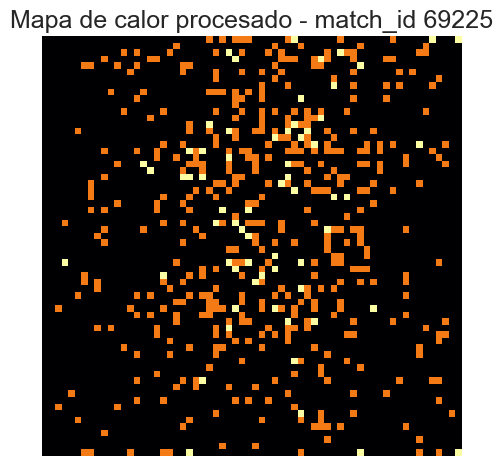

In [21]:
# Diagnóstico de los mapas de calor procesados.
print("Estadísticas de X_train:")
print(f" max = {X_train.max():.4f}")
print(f" mean = {X_train.mean():.4f}")
print(f" std = {X_train.std():.4f}")
print(f" porcentaje de píxeles en cero = {np.mean(X_train == 0) * 100:.2f}%")

# Visualización de un ejemplo de referencia en escala inferno.
indice_ejemplo = 0
plt.figure(figsize=(6, 5))
plt.imshow(X_train[indice_ejemplo].squeeze(), cmap='inferno', origin='lower', vmin=0, vmax=1)
plt.title(f"Mapa de calor procesado - match_id {train_match_ids[indice_ejemplo]}")
plt.axis('off')
plt.tight_layout()
plt.show()


## 3. Arquitectura del autoencoder

El encoder comprime cada mapa de calor en una representación latente compacta usando tres bloques convolucionales. El decoder reconstruye la imagen original de manera simétrica. Cuando el modelo recibe un partido fuera de la distribución aprendida, la reconstrucción empeora y el error sube.


In [22]:
# Arquitectura convolucional con mayor capacidad para mapas 64x64.
input_shape = (64, 64, 1)

inputs = layers.Input(shape=input_shape, name="heatmap_input")

# Encoder
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
latent = layers.MaxPooling2D((2, 2), padding="same", name="latent_space")(x)

# Decoder
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(latent)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)

outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="reconstruction")(x)

modelo = models.Model(inputs, outputs, name="conv_autoencoder_barca_larger")
modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="mse")
modelo.summary()


Model: "conv_autoencoder_barca_larger"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ heatmap_input (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv2D)         │ (None, 64, 64, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,761 (194.38 KB)

 Trainable params: 49,761 (194.38 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento del modelo

El autoencoder se entrena para reconstruir la entrada como salida objetivo. Usamos una partición interna de validación para vigilar el sobreajuste y una `batch_size` pequeña, que es importante para este tipo de práctica con pocos partidos por temporada.


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.1406 - val_loss: 0.0872
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0854 - val_loss: 0.0836
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0839 - val_loss: 0.0833
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0837 - val_loss: 0.0832
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0835 - val_loss: 0.0829
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0773 - val_loss: 0.0692
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0683 - val_loss: 0.0681
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0673 - val_loss: 0.0676
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0668 - val_loss: 0.0670
Epoch 10/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0662 - val_loss: 0.0666
Epoch 11/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0658 - val_loss: 0.0661
Epoch 12/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

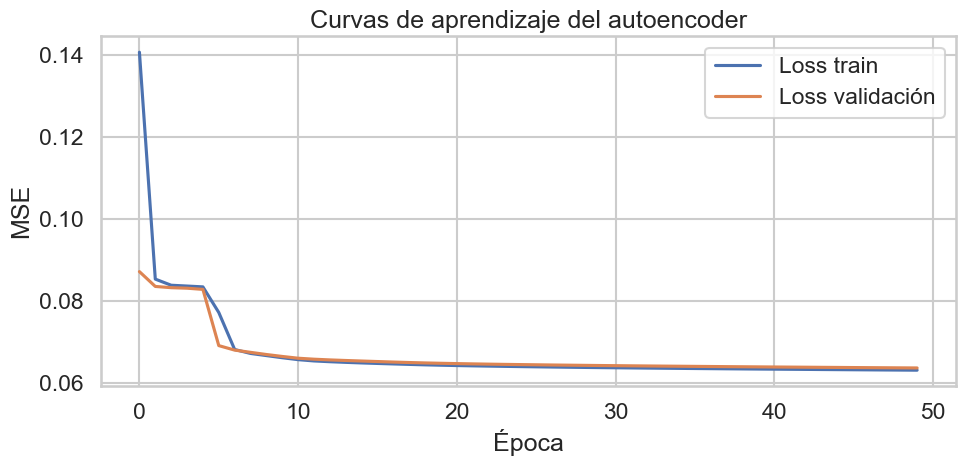

In [23]:
# Entrenamiento supervisado del autoencoder: la salida objetivo es la propia entrada.
history = modelo.fit(
    X_train,
    X_train,
    validation_split=0.15,
    epochs=50,
    batch_size=4,
    shuffle=True,
    verbose=1,
)

# Curvas de pérdida para evaluar convergencia y posible sobreajuste.
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Loss train")
plt.plot(history.history["val_loss"], label="Loss validación")
plt.title("Curvas de aprendizaje del autoencoder")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

# Reconstrucciones sobre el conjunto de test histórico/crisis.
reconstrucciones = modelo.predict(X_test, verbose=0)


## 5. Auditoría táctica y resultados

En el conjunto de crisis calculamos el MSE individual por partido. El menor error identifica el encuentro más parecido al patrón histórico aprendido; el mayor error señala el caso más alejado de esa identidad táctica.


Partido con MENOR MSE dentro de test: índice=31, match_id=70302, mse=0.040234
Partido con MAYOR MSE dentro de test: índice=90, match_id=303610, mse=0.083901


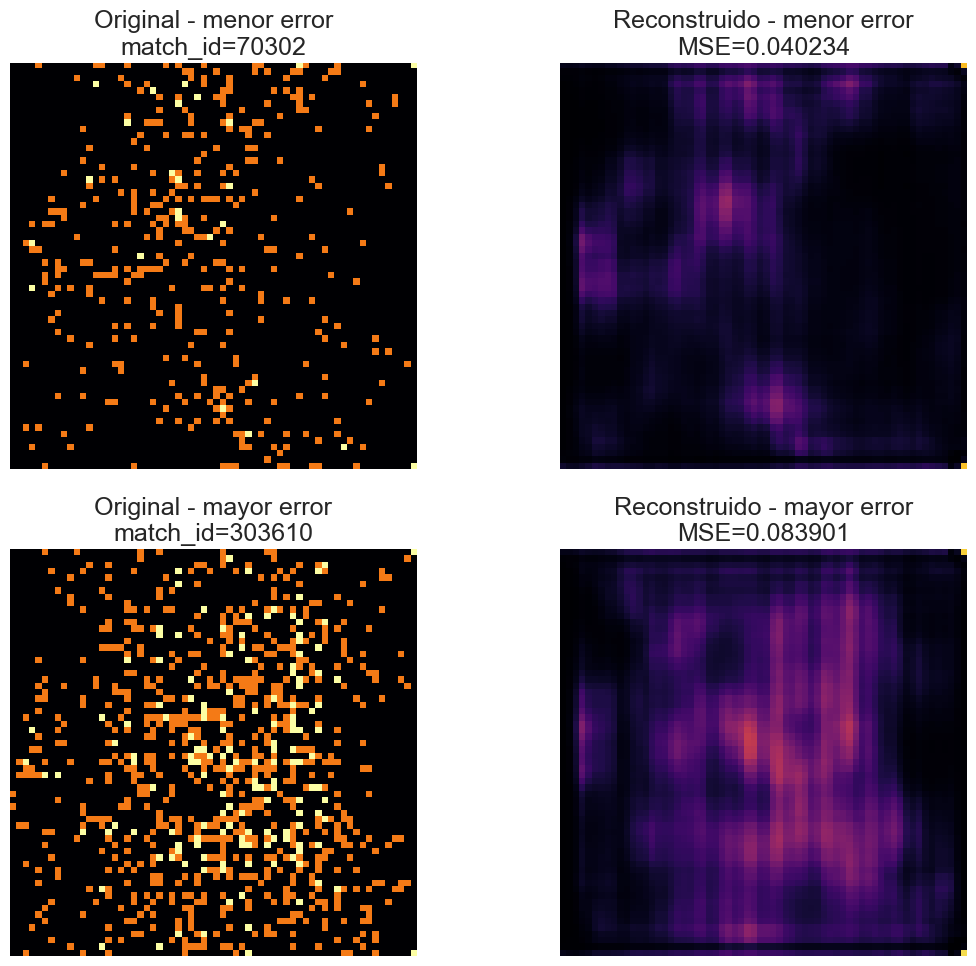

In [24]:
# Reconstrucción sobre el conjunto de prueba.
if len(X_test) == 0:
    raise ValueError("X_test está vacío; no es posible calcular anomalías.")

# Error cuadrático medio por partido: promedio sobre todas las celdas del mapa y el canal.
mse_por_partido = np.mean((X_test - reconstrucciones) ** 2, axis=(1, 2, 3))

indice_menor_error = int(np.argmin(mse_por_partido))
indice_mayor_error = int(np.argmax(mse_por_partido))

match_id_menor_error = test_match_ids[indice_menor_error]
match_id_mayor_error = test_match_ids[indice_mayor_error]

print(
    f"Partido con MENOR MSE dentro de test: índice={indice_menor_error}, "
    f"match_id={match_id_menor_error}, mse={mse_por_partido[indice_menor_error]:.6f}"
)
print(
    f"Partido con MAYOR MSE dentro de test: índice={indice_mayor_error}, "
    f"match_id={match_id_mayor_error}, mse={mse_por_partido[indice_mayor_error]:.6f}"
)

# Figura comparativa 2x2 para la interpretación visual del error de reconstrucción.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(X_test[indice_menor_error].squeeze(), cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[0, 0].set_title(f"Original - menor error\nmatch_id={match_id_menor_error}")
axes[0, 0].axis("off")

axes[0, 1].imshow(reconstrucciones[indice_menor_error].squeeze(), cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[0, 1].set_title(f"Reconstruido - menor error\nMSE={mse_por_partido[indice_menor_error]:.6f}")
axes[0, 1].axis("off")

axes[1, 0].imshow(X_test[indice_mayor_error].squeeze(), cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[1, 0].set_title(f"Original - mayor error\nmatch_id={match_id_mayor_error}")
axes[1, 0].axis("off")

axes[1, 1].imshow(reconstrucciones[indice_mayor_error].squeeze(), cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[1, 1].set_title(f"Reconstruido - mayor error\nMSE={mse_por_partido[indice_mayor_error]:.6f}")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## 6. Métricas ampliadas y visualización de anomalías

Además del ejemplo visual de mejor y peor reconstrucción, añadimos métricas agregadas para entender mejor el comportamiento del autoencoder: distribución de errores, ranking de partidos, umbral de anomalía aprendido en entrenamiento y resumen por temporada. Esto ayuda a defender el análisis de forma más rigurosa en la práctica y en la exposición final.


In [ ]:
# Métricas ampliadas y visualización de anomalías.
# Reconstruimos también el entrenamiento para definir un umbral de referencia con la propia distribución histórica.
reconstrucciones_train = modelo.predict(X_train, verbose=0)

mse_train = np.mean((X_train - reconstrucciones_train) ** 2, axis=(1, 2, 3))
mae_train = np.mean(np.abs(X_train - reconstrucciones_train), axis=(1, 2, 3))
rmse_train = np.sqrt(mse_train)

mse_test = mse_por_partido
mae_test = np.mean(np.abs(X_test - reconstrucciones), axis=(1, 2, 3))
rmse_test = np.sqrt(mse_test)

# Umbral robusto de anomalía a partir de la distribución de entrenamiento.
threshold_mean = float(mse_train.mean())
threshold_std = float(mse_train.std())
anomaly_threshold = float(np.percentile(mse_train, 95))

anomalous_mask = mse_test > anomaly_threshold
anomalous_count = int(anomalous_mask.sum())
anomalous_rate = anomalous_count / len(mse_test)

print("Resumen de métricas del entrenamiento:")
print(f"  MSE medio = {threshold_mean:.6f}")
print(f"  MSE std   = {threshold_std:.6f}")
print(f"  Umbral 95 = {anomaly_threshold:.6f}")
print()
print("Resumen de métricas del test:")
print(f"  MSE medio = {float(mse_test.mean()):.6f}")
print(f"  MAE medio = {float(mae_test.mean()):.6f}")
print(f"  RMSE medio = {float(rmse_test.mean()):.6f}")
print(f"  Partidos por encima del umbral = {anomalous_count}/{len(mse_test)} ({anomalous_rate*100:.1f}%)")

# Tabla ordenada de partidos de test por error de reconstrucción.
resultados_test = pd.DataFrame({
    "match_id": test_match_ids,
    "season_id": df_test.groupby("match_id", sort=False)["season_id"].first().to_list(),
    "mse": mse_test,
    "mae": mae_test,
    "rmse": rmse_test,
    "anomalous": anomalous_mask,
}).sort_values("mse", ascending=False).reset_index(drop=True)

print("\nTop 10 partidos con mayor error:")
print(resultados_test.head(10).to_string(index=False))

# 1) Distribución de errores en train vs test.
plt.figure(figsize=(12, 5))
sns.histplot(mse_train, bins=20, color="#2a9d8f", alpha=0.45, stat="density", label="Train", kde=True)
sns.histplot(mse_test, bins=20, color="#e76f51", alpha=0.45, stat="density", label="Test", kde=True)
plt.axvline(anomaly_threshold, color="black", linestyle="--", linewidth=2, label=f"Umbral 95% = {anomaly_threshold:.6f}")
plt.title("Distribución del error de reconstrucción")
plt.xlabel("MSE por partido")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Boxplot comparando train y test.
plt.figure(figsize=(8, 5))
comparacion_box = pd.DataFrame({
    "error": np.concatenate([mse_train, mse_test]),
    "conjunto": ["Train"] * len(mse_train) + ["Test"] * len(mse_test),
})
sns.boxplot(data=comparacion_box, x="conjunto", y="error", palette=["#2a9d8f", "#e76f51"])
plt.title("Comparación de error por conjunto")
plt.xlabel("")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

# 3) Ranking de los partidos de crisis con mayor error.
plt.figure(figsize=(12, 5))
ranking = resultados_test.head(min(10, len(resultados_test))).iloc[::-1]
plt.barh(ranking["match_id"].astype(str), ranking["mse"], color="#e76f51")
plt.axvline(anomaly_threshold, color="black", linestyle="--", linewidth=2, label="Umbral 95%")
plt.title("Top de partidos de test con mayor error")
plt.xlabel("MSE")
plt.ylabel("match_id")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Métrica agregada por temporada de test.
resumen_temporadas = resultados_test.groupby("season_id", as_index=False).agg(
    partidos=("match_id", "count"),
    mse_medio=("mse", "mean"),
    mae_medio=("mae", "mean"),
    rmse_medio=("rmse", "mean"),
    tasa_anomalias=("anomalous", "mean"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=resumen_temporadas, x="season_id", y="mse_medio", ax=axes[0], color="#e76f51")
axes[0].axhline(anomaly_threshold, color="black", linestyle="--", linewidth=2)
axes[0].set_title("MSE medio por temporada de crisis")
axes[0].set_xlabel("season_id")
axes[0].set_ylabel("MSE medio")

sns.barplot(data=resumen_temporadas, x="season_id", y="tasa_anomalias", ax=axes[1], color="#264653")
axes[1].set_title("Tasa de partidos anómalos por temporada")
axes[1].set_xlabel("season_id")
axes[1].set_ylabel("Proporción")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 5) Comparación visual promedio entre la identidad aprendida y el test completo.
promedio_train = X_train.mean(axis=0).squeeze()
promedio_test = X_test.mean(axis=0).squeeze()
promedio_recon_train = reconstrucciones_train.mean(axis=0).squeeze()
promedio_recon_test = reconstrucciones.mean(axis=0).squeeze()

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(promedio_train, cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[0, 0].set_title("Promedio real Train")
axes[0, 0].axis("off")

axes[0, 1].imshow(promedio_recon_train, cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[0, 1].set_title("Promedio reconstruido Train")
axes[0, 1].axis("off")

axes[1, 0].imshow(promedio_test, cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[1, 0].set_title("Promedio real Test")
axes[1, 0].axis("off")

axes[1, 1].imshow(promedio_recon_test, cmap="inferno", origin="lower", vmin=0, vmax=1)
axes[1, 1].set_title("Promedio reconstruido Test")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [25]:
# Resumen final del entrenamiento y guardado del modelo
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history.get('val_loss', [None])[-1]
print(f"Final train loss: {final_train_loss:.6f}")
if final_val_loss is not None:
    print(f"Final val loss:   {final_val_loss:.6f}")

# Guardar el modelo entrenado en formato HDF5.
model_path = 'autoencoder_barca_model.h5'
modelo.save(model_path)
print(f"Modelo guardado en: {model_path}")


Final train loss: 0.063214
Final val loss:   0.063757
Modelo guardado en: autoencoder_barca_model.h5
